In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA


In [3]:
# Create date range
date_range = pd.date_range(start='2015-01-01', end='2023-12-01', freq='MS')
np.random.seed(42)
data = pd.DataFrame({
    'Month': date_range,
    'Visitors': (np.random.poisson(8000, size=len(date_range)) +
                 500 * np.sin(2 * np.pi * date_range.month / 12) +
                 np.linspace(0, 3000, len(date_range))).astype(int)
})
data.set_index('Month', inplace=True)


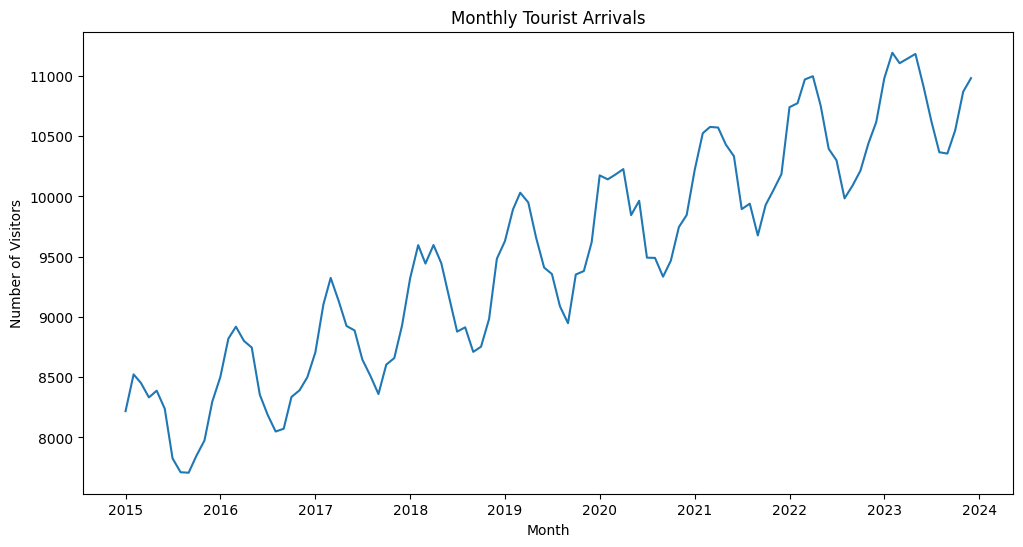

In [4]:
plt.figure(figsize=(12,6))
sns.lineplot(data=data, x=data.index, y='Visitors')
plt.title('Monthly Tourist Arrivals')
plt.xlabel('Month')
plt.ylabel('Number of Visitors')
plt.show()


In [5]:
model = ARIMA(data['Visitors'], order=(2,1,2))  # (p,d,q) values
model_fit = model.fit()
forecast = model_fit.forecast(steps=12)


/Users/avi/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/avi/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/avi/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


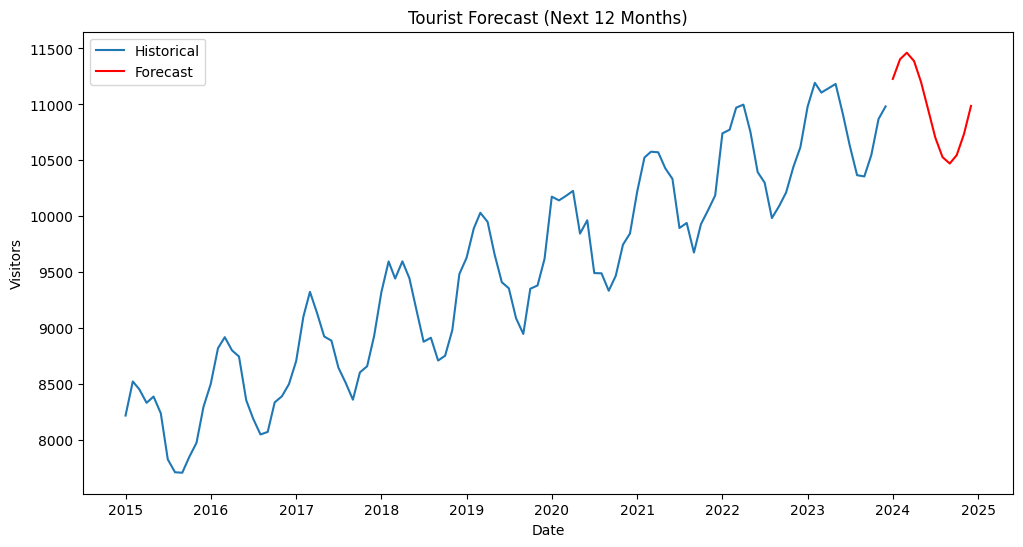

In [6]:
plt.figure(figsize=(12,6))
plt.plot(data.index, data['Visitors'], label='Historical')
future_dates = pd.date_range(start=data.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')
plt.plot(future_dates, forecast, label='Forecast', color='red')
plt.title("Tourist Forecast (Next 12 Months)")
plt.xlabel("Date")
plt.ylabel("Visitors")
plt.legend()
plt.show()


In [7]:
forecast_df = pd.DataFrame({'Month': future_dates, 'Forecasted_Visitors': forecast})
forecast_df.to_csv('tourism_forecast_arima.csv', index=False)
